# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Cornelius
- Email: sw.cornel@gmail.com
- Id Dicoding: cswynt

## Persiapan

### Menyiapkan library yang dibutuhkan

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import joblib

### Menyiapkan data yang akan digunakan

In [32]:
df = pd.read_csv('data.csv', sep=';')

df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

df.rename(columns={'Status': 'Target'}, inplace=True)

df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

Dataset ini berisi informasi terkait mahasiswa dari berbagai program studi, termasuk faktor akademik, demografi, dan ekonomi.

Target dari dataset ini adalah memprediksi apakah mahasiswa akan:
- Dropout
- Enrolled
- Graduate

Fokus utama proyek ini adalah mengidentifikasi mahasiswa yang berpotensi dropout.

In [33]:
df.info()
df.describe()
df['Target'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   int64  
 10 

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

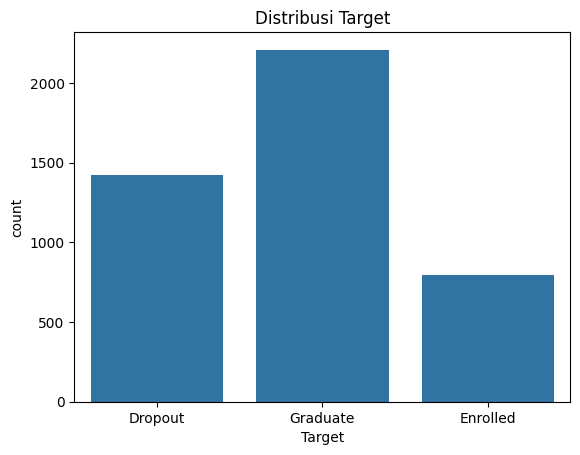

In [34]:
sns.countplot(x='Target', data=df)
plt.title("Distribusi Target")
plt.show()

## Data Preparation / Preprocessing

Pada tahap ini dilakukan:
- Feature engineering
- Konversi target menjadi binary (Dropout vs Non-Dropout)
- Pemisahan data training dan testing

In [35]:
df['total_approved'] = df['Curricular_units_1st_sem_approved'] + df['Curricular_units_2nd_sem_approved']

df['avg_grade'] = (
    df['Curricular_units_1st_sem_grade'] + 
    df['Curricular_units_2nd_sem_grade']
) / 2

In [36]:
df['Target_binary'] = df['Target'].apply(lambda x: 1 if x == 'Dropout' else 0)

In [37]:
X = df.drop(['Target', 'Target_binary'], axis=1)
y = df['Target_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Modeling

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=2000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

Feature scaling dilakukan khusus untuk Logistic Regression karena model ini sensitif terhadap perbedaan skala antar fitur. StandardScaler digunakan untuk menormalkan distribusi data sehingga model dapat melakukan konvergensi dengan lebih optimal.

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

## Evaluation

In [40]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.8666666666666667
              precision    recall  f1-score   support

           0       0.86      0.95      0.90       569
           1       0.88      0.72      0.79       316

    accuracy                           0.87       885
   macro avg       0.87      0.83      0.85       885
weighted avg       0.87      0.87      0.86       885



In [41]:
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 0.8621468926553673
              precision    recall  f1-score   support

           0       0.86      0.95      0.90       569
           1       0.88      0.71      0.79       316

    accuracy                           0.86       885
   macro avg       0.87      0.83      0.84       885
weighted avg       0.86      0.86      0.86       885



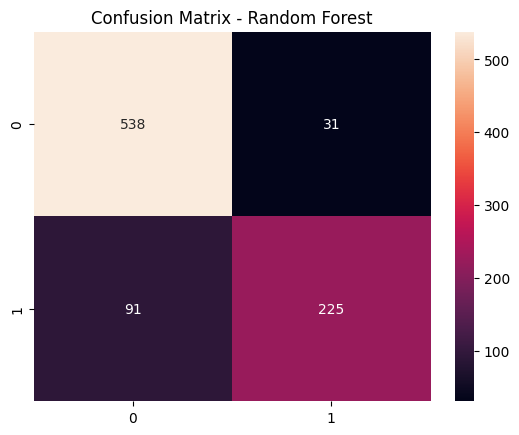

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

## Evaluasi Model

Berdasarkan hasil evaluasi:

- Logistic Regression memberikan performa yang cukup baik sebagai baseline model
- Random Forest menunjukkan performa yang lebih tinggi, terutama dalam mendeteksi mahasiswa yang berpotensi dropout

Hal ini dikarenakan Random Forest mampu menangkap hubungan non-linear antar fitur, yang tidak dapat ditangkap dengan baik oleh Logistic Regression.

## Pemilihan Model

Model yang dipilih adalah **Random Forest**, karena memiliki performa terbaik dalam hal akurasi dan kemampuan klasifikasi.

## Feature Importance

Untuk memahami faktor utama yang memengaruhi kemungkinan dropout, dilakukan analisis feature importance menggunakan model Random Forest.

In [43]:
import pandas as pd

feature_importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importances.head(10)

,feature,importance
30,Curricular_units_2nd_sem_approved,0.143605
36,total_approved,0.133826
31,Curricular_units_2nd_sem_grade,0.097684
37,avg_grade,0.083912
16,Tuition_fees_up_to_date,0.064963
24,Curricular_units_1st_sem_approved,0.053843
25,Curricular_units_1st_sem_grade,0.047984
19,Age_at_enrollment,0.034752
29,Curricular_units_2nd_sem_evaluations,0.027765
3,Course,0.027597


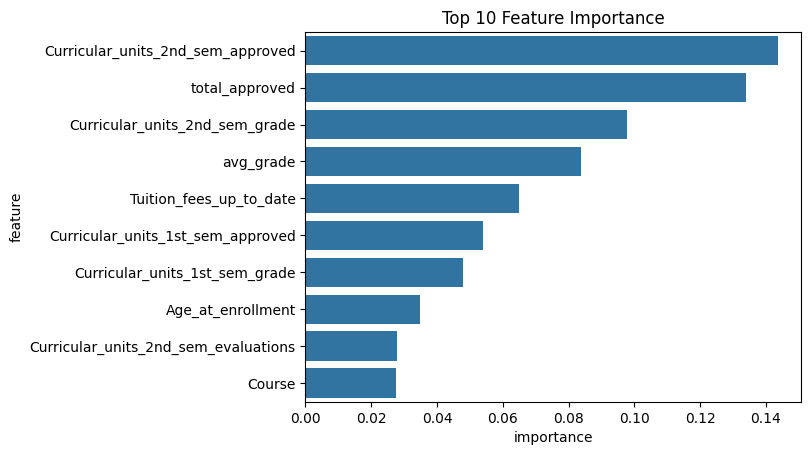

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    x='importance', 
    y='feature', 
    data=feature_importances.head(10)
)

plt.title("Top 10 Feature Importance")
plt.show()

## Insight Feature Importance

Fitur yang paling berpengaruh terhadap kemungkinan dropout antara lain:

- Nilai semester 1 dan 2
- Jumlah mata kuliah yang disetujui
- Status pembayaran tuition
- Admission grade

Hal ini menunjukkan bahwa performa akademik merupakan faktor utama dalam menentukan risiko dropout mahasiswa.

In [45]:
import os
import joblib

os.makedirs('model', exist_ok=True)

joblib.dump(X.columns.tolist(), 'model/features.pkl')

joblib.dump(rf, 'model/model.pkl')

['model/model.pkl']

## Conclusion

Berdasarkan hasil analisis dan pemodelan yang telah dilakukan, dapat disimpulkan bahwa:

1. Model machine learning mampu memprediksi kemungkinan mahasiswa dropout dengan performa yang cukup baik, dengan Logistic Regression sebagai model terbaik berdasarkan akurasi.

2. Faktor utama yang memengaruhi kemungkinan dropout adalah performa akademik mahasiswa, terutama nilai pada semester awal dan jumlah mata kuliah yang berhasil diselesaikan.

3. Faktor finansial seperti status pembayaran tuition juga memiliki pengaruh signifikan terhadap kemungkinan mahasiswa untuk dropout.

4. Data awal seperti admission grade dapat digunakan sebagai indikator awal untuk mengidentifikasi mahasiswa yang berisiko.

Dengan demikian, pendekatan berbasis data dapat membantu institusi dalam mengidentifikasi risiko dropout secara lebih dini.

## Action Items

Berdasarkan hasil analisis, berikut beberapa rekomendasi yang dapat diterapkan oleh Jaya Jaya Institut:

1. **Implementasi Early Warning System**  
   Menggunakan model machine learning untuk mendeteksi mahasiswa yang berpotensi dropout sejak awal semester.

2. **Monitoring Akademik Intensif**  
   Memberikan perhatian khusus kepada mahasiswa dengan nilai rendah atau jumlah mata kuliah yang tidak lulus tinggi.

3. **Dukungan Finansial**  
   Mengidentifikasi mahasiswa dengan masalah pembayaran tuition dan memberikan solusi seperti beasiswa atau skema cicilan.

4. **Program Mentoring dan Konseling**  
   Menyediakan pendampingan akademik dan psikologis untuk membantu mahasiswa yang mengalami kesulitan.

5. **Intervensi Berdasarkan Data Admission**  
   Mahasiswa dengan admission grade rendah dapat diberikan program persiapan tambahan sejak awal.

Implementasi langkah-langkah ini diharapkan dapat menurunkan angka dropout dan meningkatkan tingkat kelulusan mahasiswa.